In [3]:
# import pandas as pd
# import matplotlib.pyplot as plt
# from glob import glob
# from statsmodels.tsa.statespace.sarimax import SARIMAX



# # Step 1: Load and concatenate all csv.gz files
# file_paths = sorted(glob("./csv_files/*.csv.gz"))  # Or provide full path like "data/*.csv.gz"
# df_list = [pd.read_csv(file) for file in file_paths]
# input(f"Loaded {len(df_list)} files.")
# df = pd.concat(df_list, ignore_index=True)


# # Step 2: Prepare the datetime index
# df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y%m%d-%H%M%S')
# df.set_index('timestamp', inplace=True)
# df.sort_index(inplace=True)

# # Step 3: Select the target series
# y = df['packet_count']
# input(f"Data loaded with {len(y)} records.")

# # Step 4: Build and fit SARIMA model
# # You can tune (p,d,q) and seasonal (P,D,Q,s) further
# model = SARIMAX(y,
#                 order=(1, 1, 1),
#                 seasonal_order=(1, 1, 1, 60),  # assuming 60-minute seasonality
#                 enforce_stationarity=False,
#                 enforce_invertibility=False)
# input("Fitting SARIMA model...")
# results = model.fit()
# input("Model fitted.")

# # Step 5: Forecast future traffic
# n_steps = 200  # adjust as needed
# forecast = results.get_forecast(steps=n_steps)
# conf_int = forecast.conf_int()
# forecast_index = pd.date_range(start=y.index[-1], periods=n_steps + 1, freq='T')[1:]
# input(f"Forecasting {n_steps} steps ahead.")
# # Step 6: Plot it
# plt.figure(figsize=(14, 6))
# plt.plot(y[-1000:], label='Historical (last 1000)')
# plt.plot(forecast_index, forecast.predicted_mean, label='Forecast', color='orange')
# plt.fill_between(forecast_index,
#                  conf_int.iloc[:, 0],
#                  conf_int.iloc[:, 1],
#                  color='lightgray', alpha=0.5)
# plt.title("SARIMA Forecast on packet_count")
# plt.xlabel("Time")
# plt.ylabel("Packet Count")
# plt.legend()
# plt.tight_layout()
# plt.show()


import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import tqdm
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from pmdarima import auto_arima

import os

# === CONFIG ===
os.makedirs("results", exist_ok=True)
seasonal_period = 60  # Adjust based on your data resolution (e.g., 60 mins)
forecast_plot = "results/sarima_packet_count_prediction.png"

# === Load & Combine CSVs ===
file_paths = sorted(glob("./csv_files/*.csv.gz"))
df_list = [pd.read_csv(file) for file in file_paths]
df = pd.concat(df_list, ignore_index=True)

print(f"Loaded {len(df_list)} files.")
# === Parse timestamp and set index ===
# Resample before splitting into train/test
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y%m%d-%H%M%S')
print(df.head())
print(len(df))
df.set_index('timestamp', inplace=True)
df.sort_index(inplace=True)
# df = df.resample('2T').mean()  # '5T' = 5-minute intervals
df = df.resample('5T').mean().fillna(method='ffill')

print(len(df))

print(f"Data loaded with {len(df)} records.")
# === Split into train/test ===
train_df = df[df.index.date < pd.to_datetime("2021-01-14").date()]
test_df = df[df.index.date == pd.to_datetime("2021-01-14").date()]

y_train = train_df['packet_count']
y_true = test_df['packet_count'].values
n_steps = len(test_df)

print(f"y_train shape: {y_train.shape}")
print(f"NaNs: {y_train.isna().sum()}")
print(f"Unique values: {y_train.nunique()}")
print(f"Range: {y_train.min()} to {y_train.max()}\n\n")

input("Press Enter to continue...")

# === Fit SARIMA using auto_arima (FAST) ===
# print("Fitting SARIMA model with auto_arima (this will show progress)...")
# model = auto_arima(y_train,
#                    seasonal=True,
#                    m=seasonal_period,
#                    trace=True,
#                    stepwise=True,
#                    suppress_warnings=True,
#                    error_action='ignore',
#                    n_jobs=-1)

import time
with tqdm(total=1, desc="SARIMA (auto_arima)", bar_format="{l_bar}{bar} [elapsed: {elapsed}]", leave=True) as pbar:
    start = time.time()
    model = auto_arima(
                        y_train,
                        seasonal=True,
                        m=24,  # Assuming 24x5min = 2 hours of seasonality; change as needed
                        stepwise=True,
                        trace=True,
                        suppress_warnings=True,
                        error_action='ignore',
                        maxiter=25,             # Cap optimization iterations
                        max_p=2, max_q=2,       # Restrict autoregressive & moving avg terms
                        max_d=1,                # Only one differencing term
                        max_P=1, max_Q=1,       # Seasonal terms
                        max_D=1,
                        max_order=5,       # Cap total order
                       )
    pbar.update(1)
    end = time.time()
    print(f"✅ SARIMA model fitted in {end - start:.2f} seconds.")

# === Forecast ===
y_pred = model.predict(n_periods=n_steps)
forecast_index = test_df.index


Loaded 7 files.
            timestamp  packet_count  avg_packet_size  flow_count  tcp_count  \
0 2021-01-08 00:00:58         12677             64.0       11272      12451   
1 2021-01-08 00:00:59         17122             64.0       14660      16713   
2 2021-01-08 00:01:00         17882             64.0       15650      17462   
3 2021-01-08 00:01:01         62585             64.0       58974      62144   
4 2021-01-08 00:01:02         89039             64.0       55549      88625   

   udp_count  
0          0  
1          0  
2          0  
3          0  
4          0  
563847
2017
Data loaded with 2017 records.
y_train shape: (1728,)
NaNs: 0
Unique values: 1596
Range: 1.7692307692307692 to 87088.38




SARIMA (auto_arima):   0%|           [elapsed: 00:00]

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[24] intercept   : AIC=33844.151, Time=28.02 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=37010.986, Time=0.06 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=33856.248, Time=7.91 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=35471.396, Time=13.39 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=40227.718, Time=0.04 sec
 ARIMA(2,0,2)(0,0,1)[24] intercept   : AIC=33840.157, Time=14.54 sec
 ARIMA(2,0,2)(0,0,0)[24] intercept   : AIC=33839.114, Time=0.90 sec
 ARIMA(2,0,2)(1,0,0)[24] intercept   : AIC=33840.033, Time=26.00 sec
 ARIMA(1,0,2)(0,0,0)[24] intercept   : AIC=33838.506, Time=0.64 sec
 ARIMA(1,0,2)(1,0,0)[24] intercept   : AIC=33839.328, Time=16.81 sec
 ARIMA(1,0,2)(0,0,1)[24] intercept   : AIC=33839.761, Time=6.85 sec
 ARIMA(1,0,2)(1,0,1)[24] intercept   : AIC=33839.409, Time=28.67 sec
 ARIMA(0,0,2)(0,0,0)[24] intercept   : AIC=34861.790, Time=2.25 sec
 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=33848.288, Time=0.45 sec

SARIMA (auto_arima): 100%|██████████ [elapsed: 02:28]

 ARIMA(2,0,1)(0,0,0)[24] intercept   : AIC=33848.721, Time=1.55 sec
 ARIMA(1,0,2)(0,0,0)[24]             : AIC=33876.423, Time=0.13 sec

Best model:  ARIMA(1,0,2)(0,0,0)[24] intercept
Total fit time: 148.444 seconds
✅ SARIMA model fitted in 148.45 seconds.


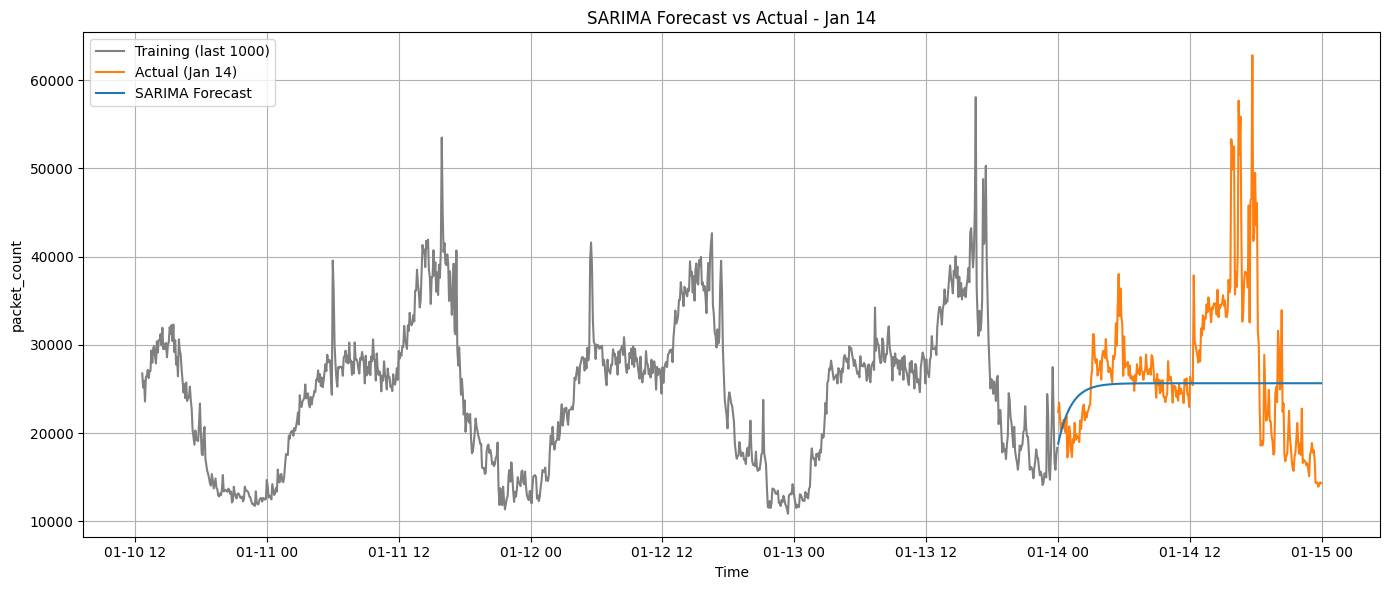

📈 Plot saved to: results/sarima_packet_count_prediction.png

📊 SARIMA Evaluation Metrics:
MAE   : 5745.40
RMSE  : 8227.65
MAPE  : 21.01%
Accuracy within 10%: 37.85%


In [4]:

# === Plot ===
plt.figure(figsize=(14, 6))
# plt.plot(train_df.index[-1000:], train_df['packet_count'], label='Training (last 1000)', color='gray')
plt.plot(train_df.index[-1000:], train_df['packet_count'].iloc[-1000:], label='Training (last 1000)', color='gray')
plt.plot(forecast_index, y_true, label='Actual (Jan 14)', color='tab:orange')
plt.plot(forecast_index, y_pred, label='SARIMA Forecast', color='tab:blue')
plt.title("SARIMA Forecast vs Actual - Jan 14")
plt.xlabel("Time")
plt.ylabel("packet_count")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(forecast_plot)
# plt.close()
plt.show()
print(f"📈 Plot saved to: {forecast_plot}")

# === Metrics ===
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

def accuracy_within_tolerance(preds, actuals, threshold=0.10):
    rel_error = np.abs(preds - actuals) / np.maximum(actuals, 1)
    return np.mean(rel_error <= threshold) * 100

accuracy = accuracy_within_tolerance(y_pred, y_true)

# === Print Metrics ===
print("\n📊 SARIMA Evaluation Metrics:")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"MAPE  : {mape:.2f}%")
print(f"Accuracy within 10%: {accuracy:.2f}%")
